# All Pipeline Demo

这个 notebook 会重新执行一遍完整的日频 demo 流程，并从 workspace_data 读取产物做展示。

流程包含：factor_engine 物化、factor_evaluation、factor_admission、multiple_factor_composite、holdings_gen、portfolio_backtest。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

candidates = [Path.cwd(), Path.cwd() / "demo" / "all_pipeline_demo"]
demo_dir = next(path for path in candidates if (path / "run_all_pipeline_demo.py").exists())
if str(demo_dir) not in sys.path:
    sys.path.insert(0, str(demo_dir))

from run_all_pipeline_demo import load_demo_artifacts, run_demo

summary = run_demo(force=True)
artifacts = load_demo_artifacts(summary)
pd.DataFrame(
    [{"name": key, "path": value} for key, value in summary["paths"].items()]
)

,name,path
0,demo_root,/home/yluel/share/projects/quantsociety_backen...
1,configs_root,/home/yluel/share/projects/quantsociety_backen...
2,inputs_root,/home/yluel/share/projects/quantsociety_backen...
3,reports_root,/home/yluel/share/projects/quantsociety_backen...
4,kline_root,/home/yluel/share/projects/quantsociety_backen...
5,market_data_path,/home/yluel/share/projects/quantsociety_backen...
6,factor_lake_root,/home/yluel/share/projects/quantsociety_backen...
7,evaluation_root,/home/yluel/share/projects/quantsociety_backen...
8,composite_root,/home/yluel/share/projects/quantsociety_backen...
9,signal_path,/home/yluel/share/projects/quantsociety_backen...


## 流程摘要

先看各阶段的核心数量和最终回测结果。

In [2]:
summary_overview = pd.DataFrame(
    [
        {"stage": "factor_engine", "value": len(summary["factor_engine"]), "note": "materialized factors"},
        {"stage": "factor_evaluation", "value": len(summary["factor_evaluations"]), "note": "evaluation runs"},
        {"stage": "factor_admission", "value": len(summary["factor_admissions"]), "note": "admission decisions"},
        {"stage": "composite rows", "value": summary["composite"]["rows"], "note": "signal rows"},
        {"stage": "holdings rows", "value": summary["holdings"]["rows"], "note": "final holdings rows"},
        {"stage": "backtest total_return", "value": summary["backtest"]["summary"]["total_return"], "note": "portfolio total return"},
        {"stage": "backtest sharpe", "value": summary["backtest"]["summary"]["sharpe"], "note": "portfolio sharpe"},
    ]
)
display(summary_overview)
display(pd.Series(summary["backtest"]["summary"], name="value").to_frame())

,stage,value,note
0,factor_engine,2.000000,materialized factors
1,factor_evaluation,2.000000,evaluation runs
2,factor_admission,2.000000,admission decisions
3,composite rows,68.000000,signal rows
4,holdings rows,34.000000,final holdings rows
5,backtest total_return,0.258882,portfolio total return
6,backtest sharpe,34.489649,portfolio sharpe


,value
strategy_name,all_pipeline_strategy
trade_days,18.0
total_return,0.258882
annual_return,24.106751
annual_volatility,0.094173
sharpe,34.489649
sortino,NaN
calmar,NaN
max_drawdown,0.0
monthly_win_rate,1.0


## 因子评估与入库

这里展示两条 demo 因子的评估指标和入库决策。

,factor_id,horizon,ic_mean,rank_ic_mean,long_short_total_return,long_short_sharpe
0,all_pipeline_close_rank_v1,1,0.994988,1.0,0.345868,2.823045e+07
1,all_pipeline_close_rank_v1,3,0.995525,1.0,0.345868,2.823045e+07
2,all_pipeline_close_rank_v1,5,0.996031,1.0,0.345868,2.823045e+07
3,all_pipeline_volume_rank_v1,1,0.994988,1.0,0.319479,2.959343e+07
4,all_pipeline_volume_rank_v1,3,0.995525,1.0,0.319479,2.959343e+07
5,all_pipeline_volume_rank_v1,5,0.996031,1.0,0.319479,2.959343e+07


,factor_id,decision,approved,reason,latest_status
0,all_pipeline_close_rank_v1,approved,True,rule_based approval,approved
1,all_pipeline_volume_rank_v1,approved,True,rule_based approval,approved


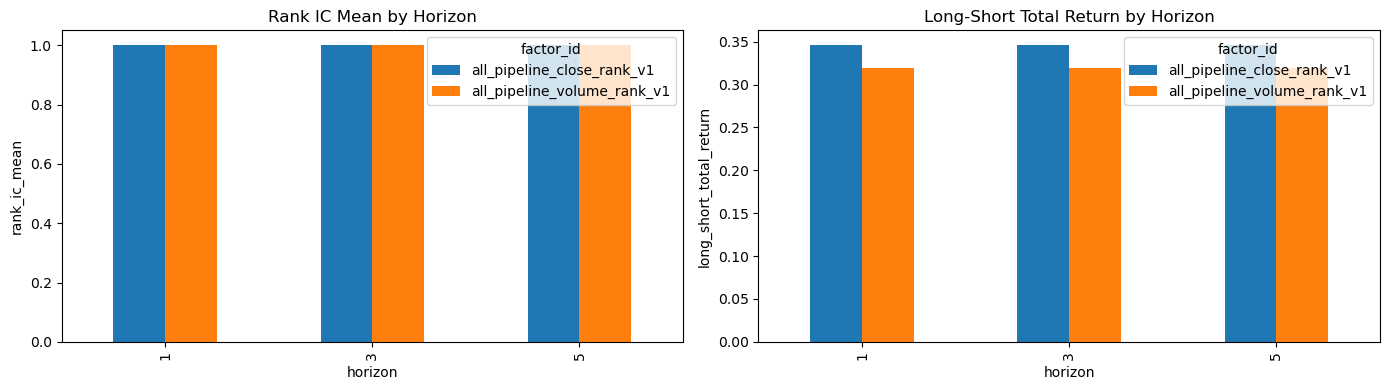

In [3]:
evaluation_summary = artifacts["evaluation_summary"].copy()
admission_summary = artifacts["admission_summary"].copy()
display(evaluation_summary[["factor_id", "horizon", "ic_mean", "rank_ic_mean", "long_short_total_return", "long_short_sharpe"]])
display(admission_summary)

rank_ic = evaluation_summary.pivot(index="horizon", columns="factor_id", values="rank_ic_mean")
ls_return = evaluation_summary.pivot(index="horizon", columns="factor_id", values="long_short_total_return")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
rank_ic.plot(kind="bar", ax=axes[0], title="Rank IC Mean by Horizon")
axes[0].set_ylabel("rank_ic_mean")
ls_return.plot(kind="bar", ax=axes[1], title="Long-Short Total Return by Horizon")
axes[1].set_ylabel("long_short_total_return")
plt.tight_layout()

## 组合信号与持仓

查看 composite signal 的前几行，以及 holdings_gen 产出的最终持仓。

,timestamp,symbol,composite_score,rank,selected_flag,side
0,2024-01-03,AAA,1.00,1.0,True,LONG
1,2024-01-03,BBB,0.75,2.0,True,LONG
2,2024-01-03,CCC,0.50,3.0,False,NONE
3,2024-01-03,DDD,0.25,4.0,False,NONE
4,2024-01-04,AAA,1.00,1.0,True,LONG
5,2024-01-04,BBB,0.75,2.0,True,LONG
6,2024-01-04,CCC,0.50,3.0,False,NONE
7,2024-01-04,DDD,0.25,4.0,False,NONE
8,2024-01-05,AAA,1.00,1.0,True,LONG
9,2024-01-05,BBB,0.75,2.0,True,LONG


,trade_date,symbol,weight
0,2024-01-03,AAA,0.5
1,2024-01-03,BBB,0.5
2,2024-01-04,AAA,0.5
3,2024-01-04,BBB,0.5
4,2024-01-05,AAA,0.5
5,2024-01-05,BBB,0.5
6,2024-01-08,AAA,0.5
7,2024-01-08,BBB,0.5
8,2024-01-09,AAA,0.5
9,2024-01-09,BBB,0.5


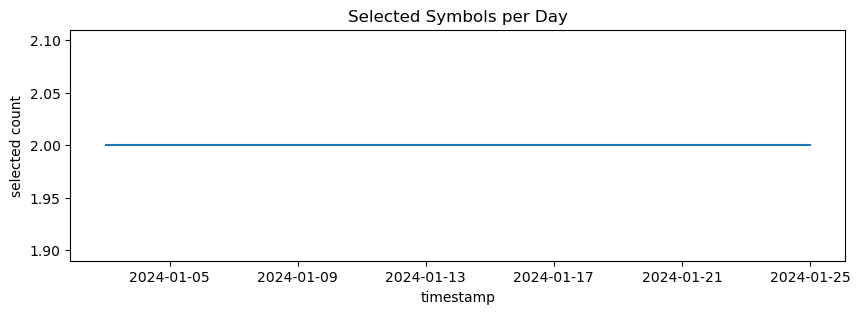

In [4]:
signal = artifacts["signal"].copy()
holdings = artifacts["holdings"].copy()
signal["timestamp"] = pd.to_datetime(signal["timestamp"])
holdings["trade_date"] = pd.to_datetime(holdings["trade_date"])

display(signal[["timestamp", "symbol", "composite_score", "rank", "selected_flag", "side"]].head(12))
display(holdings.head(12))

daily_selected = signal.groupby(signal["timestamp"].dt.date)["selected_flag"].sum()
daily_selected.plot(figsize=(10, 3), title="Selected Symbols per Day")
plt.ylabel("selected count")
plt.show()

## 组合回测结果

最后看净值曲线、回撤曲线和主要指标。

,metric,value
0,trade_days,18.000000
1,total_return,0.258882
2,gross_total_return,0.259502
3,annual_return,24.106751
4,gross_annual_return,24.280456
5,annual_volatility,0.094173
6,gross_annual_volatility,0.094358
7,sharpe,34.489649
8,gross_sharpe,34.496377
9,sortino,NaN


,trade_date,gross_return,net_return,trading_cost,turnover,holdings_count,long_exposure,short_exposure,net_exposure,gross_exposure,holding_cells,valid_holding_cells,asset_return_coverage,nav_gross,nav_net,drawdown_net,drawdown_gross,is_win_day,is_loss_day
8,2024-01-12,0.0155,0.0155,0.0,0.0,2,1.0,0.0,1.0,1.0,2,2,1.0,1.113678,1.113129,0.0,0.0,1,0
9,2024-01-15,0.0155,0.0155,0.0,0.0,2,1.0,0.0,1.0,1.0,2,2,1.0,1.130940,1.130383,0.0,0.0,1,0
10,2024-01-16,0.0155,0.0155,0.0,0.0,2,1.0,0.0,1.0,1.0,2,2,1.0,1.148469,1.147904,0.0,0.0,1,0
11,2024-01-17,0.0155,0.0155,0.0,0.0,2,1.0,0.0,1.0,1.0,2,2,1.0,1.166270,1.165696,0.0,0.0,1,0
12,2024-01-18,0.0155,0.0155,0.0,0.0,2,1.0,0.0,1.0,1.0,2,2,1.0,1.184348,1.183765,0.0,0.0,1,0
13,2024-01-19,0.0155,0.0155,0.0,0.0,2,1.0,0.0,1.0,1.0,2,2,1.0,1.202705,1.202113,0.0,0.0,1,0
14,2024-01-22,0.0155,0.0155,0.0,0.0,2,1.0,0.0,1.0,1.0,2,2,1.0,1.221347,1.220746,0.0,0.0,1,0
15,2024-01-23,0.0155,0.0155,0.0,0.0,2,1.0,0.0,1.0,1.0,2,2,1.0,1.240278,1.239667,0.0,0.0,1,0
16,2024-01-24,0.0155,0.0155,0.0,0.0,2,1.0,0.0,1.0,1.0,2,2,1.0,1.259502,1.258882,0.0,0.0,1,0
17,2024-01-25,0.0000,0.0000,0.0,0.0,2,1.0,0.0,1.0,1.0,2,0,0.0,1.259502,1.258882,0.0,0.0,0,0


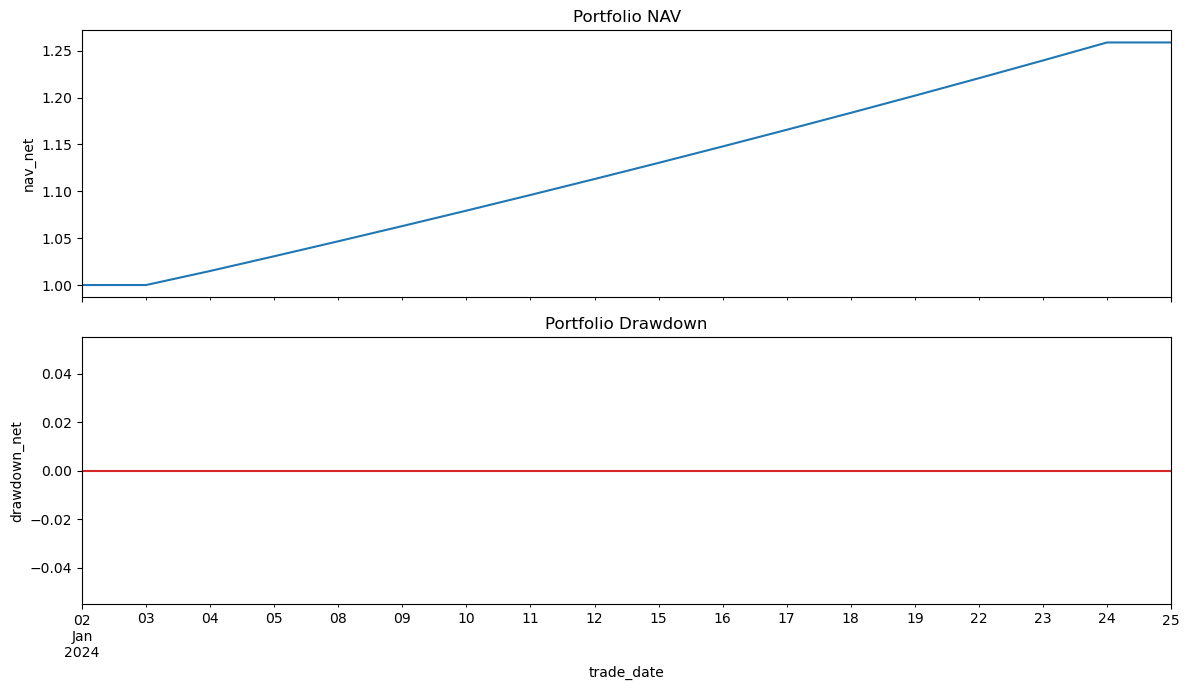

In [5]:
returns = artifacts["returns"].copy()
metrics = artifacts["metrics"].copy()
returns["trade_date"] = pd.to_datetime(returns["trade_date"])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
returns.plot(x="trade_date", y="nav_net", ax=axes[0], legend=False, title="Portfolio NAV")
axes[0].set_ylabel("nav_net")
returns.plot(x="trade_date", y="drawdown_net", ax=axes[1], color="tab:red", legend=False, title="Portfolio Drawdown")
axes[1].set_ylabel("drawdown_net")
plt.tight_layout()

display(metrics)
display(returns.tail(10))